<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



## 🆕 Version 2 — Notebook amélioré (Mission 1)Cette version reprend le notebook original du Projet 6 et y intègre les améliorations issues de la veille technologique (Étape 1) et du cahier des charges (Étape 2) :- Correction des chemins de fichiers (portabilité) et suppression d'une ligne de code redondante (valorisation du stock).- Ajout d'une **détection d'anomalies multivariée** (Isolation Forest), en complément de la méthode Z-score/IQR déjà en place — voir Étape 4.3.- Ajout d'un **test de significativité statistique (p-value)** pour les corrélations déjà présentées — voir Étape 5.5bis.Le notebook original (V1) est conservé sans modification à titre de comparaison.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

In [2]:
#Importation de la librairie plotly express
import plotly.express as px

In [3]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium

pd.set_option('display.max_columns', None)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [4]:
import warnings
warnings.simplefilter("ignore")

In [5]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")

#Importation du fichier erp.xlsx
df_liaison = pd.read_excel("liaison.xlsx")

#importation du fichier liaison.xlsx
df_erp = pd.read_excel("erp.xlsx")

#⚠️ Chemins relatifs : placez les 3 fichiers Excel dans le même dossier que ce notebook.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [6]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [7]:
#Consulter le nombre de colonnes
print(f"Nombre de colonnes : {df_erp.shape[1]}")

#La nature des données dans chacune des colonnes
print(df_erp.dtypes)

#Le nombre de valeurs présentes dans chacune des colonnes
print(df_erp.count())

df_erp.info()

Nombre de colonnes : 6
product_id          int64
onsale_web          int64
price             float64
stock_quantity      int64
stock_status          str
purchase_price    float64
dtype: object
product_id        825
onsale_web        825
price             825
stock_quantity    825
stock_status      825
purchase_price    825
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    str    
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 38.8 KB


In [8]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [9]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
print("Absence de doublons dans la colonne product_id :", df_erp["product_id"].nunique() == df_erp.shape[0])

Absence de doublons dans la colonne product_id : True


In [10]:
#Afficher les valeurs distinctes de la colonne stock_status
print(df_erp['stock_status'].unique())

#À quelle(s) autre(s) colonne(s) sont-elles liées ?
print(df_erp.groupby('stock_status')[['stock_quantity', 'price', 'purchase_price']].mean())


<StringArray>
['instock', 'outofstock']
Length: 2, dtype: str
              stock_quantity      price  purchase_price
stock_status                                           
instock            24.309686  32.194816       16.913956
outofstock         -0.086957  32.130978       17.152717


In [11]:
#Création d'une colonne "stock_status_2
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#si la valeur de la colonne "stock_quantity" est nulle renseigner "outofstock" sinon mettre "instock"
df_erp['stock_status_2'] = df_erp['stock_quantity'].apply(lambda x: 'instock' if x > 0 else 'outofstock')


In [12]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [13]:
(df_erp["stock_status"] == df_erp["stock_status_2"]).value_counts()

True     823
False      2
Name: count, dtype: int64

In [14]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
(df_erp["stock_status"] == df_erp["stock_status_2"]).sum()

np.int64(823)

In [15]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3

df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock


In [16]:
#Corriger la ou les données incohérentes
df_erp['stock_status'] = df_erp['stock_quantity'].apply(lambda x: 'outofstock' if x <= 0 else 'instock')

#Verification en utilisant le même code que plus haut pour afficher les problemes
df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


In [17]:
(df_erp["stock_status"] == df_erp["stock_status_2"]).value_counts()

True    825
Name: count, dtype: int64

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [18]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatif ou nul?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'article avec un prix non renseignés: {}".format(df_erp['price'].isna().sum()))

#Afficher le prix minimum de la colonne "price"
print("Prix minimum : {}".format(df_erp['price'].min()))

#Afficher le prix maximum de la colonne "price"
print("Prix maximum : {}".format(df_erp['price'].max()))

#Affichier les prix inférieurs à 0 (qu'est ce qu'il faut en faire ?)
df_erp[df_erp['price'] < 0]


Nombres d'article avec un prix non renseignés: 0
Prix minimum : -20.0
Prix maximum : 225.0


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock


Nous allons supprimer les prix négatifs pour éviter qu'ils viennent intervenir au niveau des calculs plus bas.

In [19]:
df_erp_clean = df_erp[df_erp["price"] >= 0].copy()

In [20]:
print(f"Nombre d'articles avec un prix négatif : {(df_erp_clean['price'] < 0).sum()}")
print(f"Taille du dataset nettoyé : {df_erp_clean.shape}")

Nombre d'articles avec un prix négatif : 0
Taille du dataset nettoyé : (822, 7)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [21]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print("Quantité minimum : {}".format(df_erp_clean['stock_quantity'].min()))

#Afficher la quantité maximum de la colonne "stock_quantity"
print("Quantité maximum : {}".format(df_erp_clean['stock_quantity'].max()))

#Affichier les stocks inférieurs à 0 (qu'est ce qu'il faut en faire ?)
df_erp_clean[df_erp_clean['stock_quantity'] < 0]


Quantité minimum : -10
Quantité maximum : 145


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,outofstock,4.96,outofstock
573,5700,1,44.5,-1,outofstock,22.30,outofstock


In [22]:
df_erp_clean.loc[df_erp_clean['stock_quantity'] < 0, 'stock_quantity'] = 0

In [23]:
print("Stock négatif restant :", (df_erp_clean['stock_quantity'] < 0).sum())

Stock négatif restant : 0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [24]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
df_erp_clean['onsale_web'].value_counts()


onsale_web
1    716
0    106
Name: count, dtype: int64

La valeur 1 de la colonne onsale_web indique que l'article et vendu sur le site. 0 indique que l'article ne l'est pas.

In [25]:
#Quelles sont les colonnes à conserver selon vous?
df_erp_clean.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,instock,23.77,instock


On conserve :
- product_id
- onsale_web
- price
- stock_quantity
- stock_status
- purchase_price


In [26]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".
df_erp_clean.drop(columns=['stock_status_2'], inplace=True)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [27]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print("Nombre de prix d'achat non renseignés : {}".format(df_erp_clean['purchase_price'].isna().sum()))

#Afficher le prix minimum de la colonne "purchase_price"
print("Prix d'achat minimum : {}".format(df_erp_clean['purchase_price'].min()))

#Afficher le prix maximum de la colonne "purchase_price"
print("Prix d'achat maximum : {}".format(df_erp_clean['purchase_price'].max()))


Nombre de prix d'achat non renseignés : 0
Prix d'achat minimum : 2.74
Prix d'achat maximum : 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [28]:
#Dimension du dataset
#Nombre d'observations
print("Nombre d'observations : {}".format(df_web.shape[0]))

#Nombre de caractéristiques
print("Nombre de caractéristiques : {}".format(df_web.shape[1]))

Nombre d'observations : 1513
Nombre de caractéristiques : 29


In [29]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
df_web.info()


<class 'pandas.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    str           
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[us]
 10  post_date_gmt          1430 non-null   datetime64[us]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   str           
 13  post_title    

In [30]:
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.count()

sku                      1428
virtual                  1513
downloadable             1513
rating_count             1513
average_rating           1430
total_sales              1430
tax_status                716
tax_class                   0
post_author              1430
post_date                1430
post_date_gmt            1430
post_content                0
product_type             1429
post_title               1430
post_excerpt              716
post_status              1430
comment_status           1430
ping_status              1430
post_password               0
post_name                1430
post_modified            1430
post_modified_gmt        1430
post_content_filtered       0
post_parent              1430
guid                     1430
menu_order               1430
post_type                1430
post_mime_type            714
comment_count            1430
dtype: int64

In [31]:
#Selon vous, quelles sont les colonnes à conserver ?


On conserve toutes les colonnes, sauf les colonnes suivantes qui contiennent 0 valeurs :
- tax_class
- post_content
- post_password
- post_content_filtered

In [32]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web_clean = df_web.copy()
cols_to_keep = [col for col in df_web_clean.columns if col not in ['tax_class', 'post_content', 'post_password', 'post_content_filtered']]
df_web_clean = df_web_clean[cols_to_keep]

In [33]:
#Visualisation des valeurs de la colonne sku
df_web_clean['sku'].unique()

#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
#'13127-1', 'bon-cadeau-25-euros' et les NaN


array([11862, 16057, 14692, 16295, 15328, 15471, 16515, 16246, nan, 13572,
       16513, 16585, 16269, 15526, 12869, 15575, 11586, 14338, 15425,
       16560, 15361, 13809, 11587, 15022, 14323, 16342, 16029, 15475,
       13754, 14680, 15875, 9636, 13849, 13662, 16564, 13557, 15429,
       14712, 15032, 15481, 15448, 16580, 15441, 804, 15300, 13958, 16071,
       15678, 13895, 15711, 12882, 16053, 13766, 16247, 12640, 15292,
       15476, 15670, 16189, 16038, 14864, 16044, 15324, 15531, 15953,
       15413, 15733, 14366, 15895, 15892, 16472, 15185, 16010, 15793,
       15849, 12315, 15741, 15934, 15148, 15781, 15659, 15106, 15490,
       14507, 14149, 16307, 13736, 14090, 16037, 15758, 14661, 12587,
       15337, 15489, 15201, 16305, 16131, 13435, 15747, 12203, 14509,
       14768, 16262, 14561, 16505, 15717, 16129, 13460, 15871, 15940,
       11602, 13127, 13520, 15480, 13032, 15436, 15269, 15910, 19821,
       16263, 15138, 15146, 15126, 15482, 16186, 13905, 16540, 15856,
       1567

In [34]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les
df_web_clean[
    df_web_clean['sku'].isna() |
    df_web_clean['sku'].astype(str).str.contains(r'[^0-9]')
]

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
8,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1387,bon-cadeau-25-euros,0,0,0,0.0,7.0,taxable,1.0,2018-06-01 13:53:46,2018-06-01 11:53:46,NaN,Bon cadeau de 25€,"<span style=""color: #a85253;""><strong>Parlons ...",publish,closed,closed,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1429,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1432,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1445,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
#Identifier les lignes sans code article
df_web_clean[df_web_clean['sku'].isnull()].info()

<class 'pandas.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                0 non-null      object        
 1   virtual            85 non-null     int64         
 2   downloadable       85 non-null     int64         
 3   rating_count       85 non-null     int64         
 4   average_rating     2 non-null      float64       
 5   total_sales        2 non-null      float64       
 6   tax_status         2 non-null      str           
 7   post_author        2 non-null      float64       
 8   post_date          2 non-null      datetime64[us]
 9   post_date_gmt      2 non-null      datetime64[us]
 10  product_type       2 non-null      str           
 11  post_title         2 non-null      str           
 12  post_excerpt       2 non-null      str           
 13  post_status        2 non-null      str           
 14  comment_status     2 non-n

In [36]:
#Pour les codes articles identifiés, réalisé une analyse et définissez l'action à entreprendre
df_web_clean[df_web_clean["sku"].isnull()][df_web_clean['total_sales'].notnull()]
#Supprimer ces articles du df afin que les ventes négatives n'impactent pas les calculs et analyses qui devraient être effectuées par la suite.

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
1084,NaN,0,0,0,0.0,-56.0,taxable,2.0,2018-08-08 11:23:43,2018-08-08 09:23:43,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,"<span id=""u1194-83"">Le nez séduit par ses parf...",publish,closed,closed,pierre-jean-villa-condrieu-suspendu-2018,2019-11-02 13:24:01,2019-11-02 12:24:01,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
1087,NaN,0,0,0,0.0,-17.0,taxable,2.0,2018-07-31 12:07:23,2018-07-31 10:07:23,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,"Fongeant 2017 explose sur un fruit brillant, p...",publish,closed,closed,pierre-jean-villa-cote-rotie-fongeant-2017,2019-11-02 13:24:15,2019-11-02 12:24:15,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [37]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
df_web_clean['sku'].duplicated().sum()

np.int64(798)

In [38]:
df_web_clean[df_web_clean['sku'].duplicated(keep=False)].assign(
    sku_str=df_web_clean['sku'].astype(str)
).sort_values(by='sku_str')

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,sku_str
668,10014,0,0,0,0.0,10.0,taxable,2.0,2019-04-04 15:45:23,2019-04-04 13:45:23,Gin,Darnley's London Dry Gin Original,"<span title="""">Un gin léger, floral et aromati...",publish,closed,closed,darnleys-london-dry-gin-original,2020-08-26 15:55:02,2020-08-26 13:55:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,10014
1030,10014,0,0,0,0.0,10.0,NaN,2.0,2019-04-04 15:45:23,2019-04-04 13:45:23,Gin,Darnley's London Dry Gin Original,NaN,publish,closed,closed,darnleys-london-dry-gin-original,2020-08-26 15:55:02,2020-08-26 13:55:02,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0,10014
887,10459,0,0,0,0.0,4.0,NaN,2.0,2018-04-13 15:58:19,2018-04-13 13:58:19,Vin,Alphonse Mellot Sancerre Rouge Génération XIX ...,NaN,publish,closed,closed,alphonse-mellot-sancerre-rouge-generation-xix-...,2020-08-24 14:05:02,2020-08-24 12:05:02,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0,10459
748,10459,0,0,0,0.0,4.0,taxable,2.0,2018-04-13 15:58:19,2018-04-13 13:58:19,Vin,Alphonse Mellot Sancerre Rouge Génération XIX ...,"Robe d'un superbe rubis, dense et profond - As...",publish,closed,closed,alphonse-mellot-sancerre-rouge-generation-xix-...,2020-08-24 14:05:02,2020-08-24 12:05:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,10459
802,10775,0,0,0,0.0,6.0,taxable,2.0,2018-04-17 21:28:52,2018-04-17 19:28:52,Vin,Albert Mann Pinot Gris Vendanges Tardives Alte...,Belle bouteille dotée d’une grande complexité ...,publish,closed,closed,albert-mann-pinot-gris-vendanges-tardives-alte...,2018-12-22 10:30:02,2018-12-22 09:30:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,10775
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1429,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1432,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1445,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
#Les lignes sans code article semble être toutes non renseignés
#Pour s'en assurer réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_sans_sku = df_web_clean[df_web_clean['sku'].isna()]

#2 - utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeur reseigner dans chacune des colonnes
df_sans_sku.info()

#3 Que constatez-vous ?
#Nous constatons que même après avoir supprimé les NaN, nous avons toujours des doublons.

<class 'pandas.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                0 non-null      object        
 1   virtual            85 non-null     int64         
 2   downloadable       85 non-null     int64         
 3   rating_count       85 non-null     int64         
 4   average_rating     2 non-null      float64       
 5   total_sales        2 non-null      float64       
 6   tax_status         2 non-null      str           
 7   post_author        2 non-null      float64       
 8   post_date          2 non-null      datetime64[us]
 9   post_date_gmt      2 non-null      datetime64[us]
 10  product_type       2 non-null      str           
 11  post_title         2 non-null      str           
 12  post_excerpt       2 non-null      str           
 13  post_status        2 non-null      str           
 14  comment_status     2 non-n

In [40]:
df_web_clean = df_web_clean[df_web_clean['sku'].notna()]

In [41]:
df_web_clean['sku'].duplicated().sum()

np.int64(714)

In [42]:
df_web_clean = df_web_clean[df_web_clean["post_type"] == "product"]

In [43]:
df_web_clean['sku'].duplicated().sum()

np.int64(0)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [44]:
#Dimension du dataset
#Nombre d'observations
print("Nombre d'observations : {}".format(df_liaison.shape[0]))

#Nombre de caractéristiques
print("Nombre d'articles : {}".format(df_liaison.shape[1]))

Nombre d'observations : 825
Nombre d'articles : 2


In [45]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.info()
print("\nNombre de valeurs présentes par colonne :")
print(df_liaison.count())

<class 'pandas.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB

Nombre de valeurs présentes par colonne :
id_web        734
product_id    825
dtype: int64


In [46]:
#Les valeurs de la colonne "product_id" sont elles toutes uniques?
if df_liaison['product_id'].nunique() == len(df_liaison):
    print("Tous les product_id sont uniques.")
else:
    print("Il y a des doublons dans product_id.")

Tous les product_id sont uniques.


In [47]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
if df_liaison['id_web'].nunique() == len(df_liaison):
    print("Tous les id_web sont uniques.")
else:
    print("Il y a des doublons dans id_web.")


Il y a des doublons dans id_web.


In [48]:
#Avons-nous des articles sans correspondances?
print(any(df_liaison["product_id"].isnull()))
print("🔎 Il y a {} articles sans correspondance dans id_web.".format(df_liaison["id_web"].isnull().sum()))


False
🔎 Il y a 91 articles sans correspondance dans id_web.


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [49]:
#Fusion des fichiers df_erp et df_liaison
df_erp_liaison = pd.merge(df_erp_clean, df_liaison, how='outer', on='product_id')

In [50]:
# Affichage des dimensions avant et après la jointure
print("Taille de df_erp :", df_erp.shape)
print("Taille de df_liaison :", df_liaison.shape)
print("Taille après jointure (df_erp_liaison) :", df_erp_liaison.shape)

Taille de df_erp : (825, 7)
Taille de df_liaison : (825, 2)
Taille après jointure (df_erp_liaison) : (825, 7)


In [51]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
#Du coup les deux fichiers sont parfaitement alignés et cahque produit de product_id dans df_erp a une correspondance dans df_liaison et vice-versa. On ne note aucune perte ou créations de lignes supplémentaires dûs à la jointure

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [52]:
print("Valeurs uniques dans id_web (ERP+liaison) :", df_erp_liaison['id_web'].nunique())
print("Valeurs uniques dans sku (Web) :", df_web_clean['sku'].nunique())

Valeurs uniques dans id_web (ERP+liaison) : 734
Valeurs uniques dans sku (Web) : 714


In [53]:
#Fusionnez les datasets df_merge et df_web
# Fusion avec jointure externe (outer join) et indicateur
df_final = pd.merge(
    df_erp_liaison,
    df_web_clean,
    left_on="id_web",
    right_on="sku",
    how="outer",
    indicator=True
)



In [54]:
#Avons-nous des lignes sans correspondances?
print("ERP + Liaison :", df_erp_liaison.shape)
print("Web clean     :", df_web_clean.shape)
print("Final (fusion):", df_final.shape)

ERP + Liaison : (825, 7)
Web clean     : (714, 25)
Final (fusion): (825, 33)


In [55]:
# Lignes qui n'ont pas matché
df_sans_correspondance = df_final[df_final["_merge"] != "both"]

# Nombre de lignes sans correspondance
print("Nombre d'articles sans correspondances : {} lignes ({}%)".format(
    df_sans_correspondance.shape[0],
    round((df_sans_correspondance.shape[0] / df_final.shape[0]) * 100, 2)
))

# Vérification des types de non-correspondance
print("Types de correspondances absentes :", df_sans_correspondance["_merge"].unique())


Nombre d'articles sans correspondances : 111 lignes (13.45%)
Types de correspondances absentes : ['left_only']
Categories (3, str): ['left_only', 'right_only', 'both']


In [56]:
# Compter les occurrences de chaque type de correspondance
presence_counts = df_final["_merge"].value_counts().reset_index()
presence_counts.columns = ["Type de présence", "Nombre"]

# Mapping pour noms explicites (optionnel mais plus clair pour la soutenance)
mapping = {
    "left_only": "Seulement ERP",
    "right_only": "Seulement Web",
    "both": "Présents dans les deux"
}
presence_counts["Type de présence"] = presence_counts["Type de présence"].map(mapping)

# Bar chart avec Plotly Express
fig = px.bar(
    presence_counts,
    x="Type de présence",
    y="Nombre",
    text="Nombre",
    title="Répartition des articles après jointure ERP / Web",
    color="Type de présence",
    color_discrete_sequence=px.colors.qualitative.Set2
)

# Mise en forme adaptée à une slide
fig.update_traces(textposition="outside")
fig.update_layout(
    width=1000,
    height=500,
    margin=dict(l=20, r=20, t=40, b=20),
    showlegend=False
)

fig.show()


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

<Axes: >

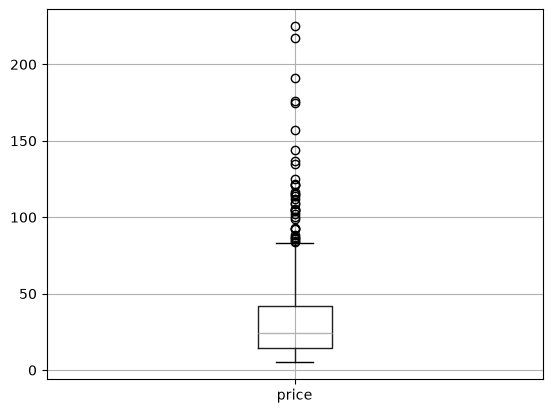

In [57]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
df_final.boxplot(column='price')

In [58]:
#Autre méthode avec plotly express
import plotly.express as px

fig = px.box(
    data_frame=df_final,
    y="price",
    title="Boîte à moustache de la répartition des prix"
)

fig.update_layout(
    width=650,
    height=700,
    margin=dict(l=20, r=20, t=50, b=40)
)

fig.show()


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [59]:
#Calculer la moyenne du prix
moyenne_price = df_final['price'].mean()
print("Moyenne des prix :", moyenne_price)

#Calculer l'écart-type du prix
ecart_type_price = df_final['price'].std()
print("Écart-type des prix :", ecart_type_price)

#Calculer le Z-score
df_final['z_score_price'] = (df_final['price'] - moyenne_price) / ecart_type_price
print("Le Z-score est de: ", df_final['z_score_price'].mean())

Moyenne des prix : 32.350304136253044
Écart-type des prix : 26.62245309964109
Le Z-score est de:  -1.0372886653432119e-16


In [60]:
#Quel est le seuil prix dont z-score est supérieur à 3?
seuil_z3 = df_final[df_final['z_score_price'] > 3]['price'].min()
print(f"✅ Le seuil minimum des prix dont le Z-score est > 3 est : {seuil_z3:.2f} €")

# Seuil des prix avec z-score > 2
seuil_z2 = df_final[df_final['z_score_price'] > 2]['price'].min()
print(f"✅ Le seuil minimum des prix dont le Z-score est > 2 est : {seuil_z2:.2f} €")


✅ Le seuil minimum des prix dont le Z-score est > 3 est : 114.00 €
✅ Le seuil minimum des prix dont le Z-score est > 2 est : 85.60 €


In [61]:
# 1️⃣ Prix dont le Z-score est > 3
fig_z3 = px.histogram(
    df_final[df_final['z_score_price'] > 3],
    x='price',
    nbins=20,
    title="Histogramme des prix avec Z-score > 3",
    labels={'price': 'Prix (€)'},
    color_discrete_sequence=['red']
)
fig_z3.update_layout(width=600, height=700, margin=dict(l=20, r=20, t=50, b=40))
fig_z3.show()

# 2️⃣ Prix dont le Z-score est > 2
fig_z2 = px.histogram(
    df_final[df_final['z_score_price'] > 2],
    x='price',
    nbins=20,
    title="Histogramme des prix avec Z-score > 2",
    labels={'price': 'Prix (€)'},
    color_discrete_sequence=['orange']
)
fig_z2.update_layout(width=600, height=700, margin=dict(l=20, r=20, t=50, b=40))
fig_z2.show()


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [62]:
#Utilisation de la fonction describe de Pandas pour l'etude des mesures de dispersions
df_erp_price_describe = df_erp[["price"]].describe()
print(df_erp_price_describe)


            price
count  825.000000
mean    32.187697
std     26.712077
min    -20.000000
25%     14.500000
50%     24.300000
75%     42.000000
max    225.000000


In [63]:
#Définissez un seuil pour les articles "outliers" en prix
q1 = df_final['price'].quantile(0.25)
q3 = df_final['price'].quantile(0.75)
iqr = q3 - q1

seuil_bas = q1 - 1.5 * iqr
seuil_haut = q3 + 1.5 * iqr

print(f"Les prix considérés comme outliers sont inférieurs à {seuil_bas:.2f} € ou supérieurs à {seuil_haut:.2f} €.")

Les prix considérés comme outliers sont inférieurs à -26.50 € ou supérieurs à 83.10 €.


In [64]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
# Reprendre les bornes de l’IQR
Q1 = df_final['price'].quantile(0.25)
Q3 = df_final['price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Identifier les outliers
outliers_iqr = df_final[df_final['price'] > upper_bound]

# Calculer leur nombre
nb_outliers = outliers_iqr.shape[0]

# Calculer la proportion
proportion = nb_outliers / df_final.shape[0] * 100

# Affichage des résultats
print(f"Nombre d'articles considérés comme outliers en prix : {nb_outliers}")
print(f"Soit environ {proportion:.2f}% du catalogue total.")

Nombre d'articles considérés comme outliers en prix : 36
Soit environ 4.36% du catalogue total.


In [65]:
outliers_iqr['product_type'].value_counts()

product_type
Vin          19
Champagne     6
Cognac        4
Whisky        3
Name: count, dtype: int64

In [66]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
outliers_iqr[['post_title', 'price', 'total_sales']].sort_values(by='price', ascending=False)

,post_title,price,total_sales
567,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.0,11.0
204,David Duband Charmes-Chambertin Grand Cru 2014,217.5,2.0
269,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.3,6.0
24,Cognac Frapin VIP XO,176.0,3.0
313,Camille Giroud Clos de Vougeot 2016,175.0,4.0
33,Cognac Frapin Château de Fontpinot 1989 20 Ans...,157.0,4.0
745,NaN,144.0,NaN
171,Domaine Des Croix Corton Charlemagne Grand Cru...,137.0,3.0
257,Champagne Gosset Célébris Vintage 2007,135.0,5.0
256,Domaine Weinbach Gewurztraminer Grand Cru Furs...,124.8,1.0


Les articles identifiés comme outliers en prix via la méthode de l’IQR sont pour la quasi-totalité des produits haut de gamme : Grands Crus, spiritueux millésimés ou champagnes d’exception. Leurs prix élevés se justifient par leur nature et sont corroborés par des ventes réelles. On ne peut donc pas conclure à des erreurs de saisie mais plutôt à une distribution normale avec une offre premium intégrée au catalogue

In [67]:
def etiquetage_outlier(personal_label, title):
    for label in [title, personal_label]:
        if isinstance(label, str):
            label = label.lower()
            if ("grand" in label or "1er" in label) and "cru" in label:
                return "Grand Cru"
            elif "champagne" in label:
                return "Champagne"
            elif "cognac" in label:
                return "Cognac"
            elif "whisky" in label:
                return "Whisky"
    return "Autre"

df_final["categorie_outlier"] = df_final[["post_name", "post_title"]].apply(
    lambda row: etiquetage_outlier(row["post_name"], row["post_title"]), axis=1
)

In [68]:
fig = px.violin(
    df_final,
    x="categorie_outlier",
    y="price",
    box=True,
    points="all",
    title="Distribution des prix par catégorie (Violin plot)",
    labels={"price": "Prix (€)", "categorie_outlier": "Catégorie"}
)
fig.update_layout(width=1500, height=500, margin=dict(l=20, r=20, t=50, b=40))
fig.show()

<div style="border: 1px solid RGB(51,165,182);" ><h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Étape 4.3 - Détection d'anomalies multivariée (Isolation Forest)</h3></div>

**Amélioration issue de la veille (Étape 1).** La détection d'outliers ci-dessus (Z-score, IQR) est univariée : elle ne regarde que la variable `price`. Elle ne peut donc pas repérer un article dont la combinaison de plusieurs variables (par exemple un stock très élevé pour un prix et un niveau de ventes par ailleurs banals) serait anormale.On applique ici un **Isolation Forest**, qui détecte les anomalies en tenant compte simultanément de `price`, `stock_quantity` et `total_sales`. Le taux de contamination est calibré sur le taux d'outliers déjà trouvé par IQR (~4,36 %), pour rester comparable.

In [69]:
#Détection d'anomalies multivariée avec Isolation Forest
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

#Sélection des variables numériques pertinentes et suppression des lignes incomplètes sur ces colonnes
colonnes_iso = ["price", "stock_quantity", "total_sales"]
df_iso = df_final.dropna(subset=colonnes_iso).copy()

#Standardisation : indispensable ici car price (échelle ~0-225) et stock_quantity (échelle ~0-145)
#n'ont pas la même échelle, ce qui biaiserait la notion de "distance" utilisée par l'algorithme
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_iso[colonnes_iso])

#Contamination calibrée sur le taux d'outliers déjà identifié par la méthode IQR (~4.36%)
iso_forest = IsolationForest(contamination=0.0436, random_state=42)
df_iso["anomalie_multivariee"] = iso_forest.fit_predict(X_scaled)

#IsolationForest retourne -1 pour une anomalie, 1 pour un point normal
nb_anomalies = (df_iso["anomalie_multivariee"] == -1).sum()
print(f"Nombre d'articles détectés comme anormaux (Isolation Forest) : {nb_anomalies}")
print(f"Soit {nb_anomalies / df_iso.shape[0] * 100:.2f}% du catalogue analysé")

Nombre d'articles détectés comme anormaux (Isolation Forest) : 32
Soit 4.48% du catalogue analysé


In [70]:
#Comparaison avec les outliers déjà identifiés par la méthode IQR (univariée sur le prix)
#Objectif : mesurer le taux de recouvrement entre les deux méthodes, selon deux définitions
articles_iqr = set(outliers_iqr.index)
articles_iso = set(df_iso[df_iso["anomalie_multivariee"] == -1].index)
recouvrement = articles_iqr & articles_iso
union_iqr_iso = articles_iqr | articles_iso

#Définition 1 : part des outliers IQR également détectés par Isolation Forest
taux_recouvrement_vs_iqr = len(recouvrement) / len(articles_iqr) * 100 if len(articles_iqr) > 0 else 0

#Définition 2 : indice de Jaccard (intersection / union des deux ensembles)
taux_recouvrement_jaccard = len(recouvrement) / len(union_iqr_iso) * 100 if len(union_iqr_iso) > 0 else 0

print(f"Articles détectés par IQR uniquement : {len(articles_iqr - articles_iso)}")
print(f"Articles détectés par Isolation Forest uniquement : {len(articles_iso - articles_iqr)}")
print(f"Articles détectés par les deux méthodes : {len(recouvrement)}")
print(f"Taux de recouvrement (intersection / IQR) : {taux_recouvrement_vs_iqr:.2f}%")
print(f"Taux de recouvrement (indice de Jaccard, intersection / union) : {taux_recouvrement_jaccard:.2f}%")

Articles détectés par IQR uniquement : 23
Articles détectés par Isolation Forest uniquement : 19
Articles détectés par les deux méthodes : 13
Taux de recouvrement (intersection / IQR) : 36.11%
Taux de recouvrement (indice de Jaccard, intersection / union) : 23.64%


In [71]:
#Visualisation : articles détectés uniquement par Isolation Forest (anomalies multivariées "invisibles" pour l'IQR)
df_iso_only = df_iso.loc[list(articles_iso - articles_iqr)]

fig = px.scatter(
    df_iso_only,
    x="price",
    y="stock_quantity",
    size="total_sales",
    color_discrete_sequence=["#E76F51"],
    title="Anomalies détectées uniquement par Isolation Forest (invisibles pour l'IQR sur le prix seul)",
    labels={"price": "Prix (€)", "stock_quantity": "Quantité en stock"}
)
fig.update_layout(width=900, height=500, margin=dict(l=40, r=40, t=60, b=40))
fig.show()

**Conclusion (résultats réels) :** l'IQR détecte 36 outliers de prix (4,36% du catalogue) et Isolation Forest détecte 32 anomalies multivariées (4,48%). Seuls 13 articles sont détectés par les deux méthodes à la fois (recouvrement de 36,11% par rapport à l'IQR, soit 23,64% en indice de Jaccard intersection/union). 19 articles ont une combinaison stock/ventes jugée anormale par Isolation Forest alors que leur prix, seul critère regardé par l'IQR, est parfaitement dans la norme : ce sont précisément les anomalies de gestion "invisibles" à l'analyse univariée du prix, la preuve chiffrée de la limite identifiée en veille technologique (Étape 1).

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [72]:
##############################
# Calculer le CA su site web #
##############################

#Créez une colonne calculant le CA par article
df_final["ca_par_article"] = df_final["price"] * df_final["total_sales"]

#Calculez la somme de la colonne "ca_par_article"
ca_total = df_final['ca_par_article'].sum()
print(f"Le chiffre d'affaires total est de {ca_total:.2f} euros.")

#Ce résultat correspond au chiffre d'affaire du site web


Le chiffre d'affaires total est de 143680.10 euros.


In [73]:
###############################
# Palmares des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_palmares_ca = df_final.sort_values(by="ca_par_article", ascending=False).reset_index(drop=True)

#Réinitialiser l'index du dataset par un reset_index
df_palmares_ca = df_palmares_ca.reset_index(drop=True)

#Afficher les 20 premier articles en CA
df_top_20_ca = df_palmares_ca.head(20)
display(df_top_20_ca)

#Graphique en barre des 20 premiers articles avec plotly express

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,_merge,z_score_price,categorie_outlier,ca_par_article
0,4352,1.0,225.0,0.0,outofstock,137.81,15940,15940,0.0,0.0,0.0,0.0,11.0,taxable,2.0,2018-03-02 10:30:04,2018-03-02 09:30:04,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,Issu d’un assemblage de 70% de Pinot Noir du g...,publish,closed,closed,champagne-egly-ouriet-grand-cru-millesime-2008,2020-03-07 11:18:45,2020-03-07 10:18:45,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,7.236362,Grand Cru,2475.0
1,5892,1.0,191.3,98.0,instock,116.06,14983,14983,0.0,0.0,0.0,0.0,6.0,taxable,2.0,2019-03-28 10:21:36,2019-03-28 09:21:36,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,Cet Ambonnay évoque les grands Pinots Noirs de...,publish,closed,closed,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,2020-04-01 09:30:09,2020-04-01 07:30:09,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,5.970513,Autre,1147.8
2,4353,1.0,79.5,127.0,instock,45.91,12587,12587,0.0,0.0,0.0,0.0,14.0,taxable,2.0,2018-03-02 10:37:26,2018-03-02 09:37:26,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,&nbsp;\n\nLe Rosé Grand Cru de la maison Egly-...,publish,closed,closed,champagne-egly-ouriet-grand-cru-brut-rose,2020-08-22 11:45:02,2020-08-22 09:45:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,1.771050,Grand Cru,1113.0
3,5826,1.0,41.2,34.0,instock,21.71,15325,15325,0.0,0.0,0.0,0.0,20.0,taxable,2.0,2019-03-27 17:59:49,2019-03-27 16:59:49,Vin,Agnès Levet Côte Rôtie Améthyste 2017,"<span style=""float: none;background-color: tra...",publish,closed,closed,agnes-levet-amethyste-2017,2020-05-21 14:00:02,2020-05-21 12:00:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,0.332415,Autre,824.0
4,6212,1.0,115.0,16.0,instock,59.42,13996,13996,0.0,0.0,0.0,0.0,7.0,taxable,2.0,2019-07-25 09:09:17,2019-07-25 07:09:17,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-16 09:30:16,2020-06-16 07:30:16,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,3.104511,Grand Cru,805.0
5,5026,1.0,86.8,101.0,instock,50.13,13913,13913,0.0,0.0,0.0,0.0,9.0,taxable,2.0,2018-07-18 10:46:30,2018-07-18 08:46:30,Champagne,Champagne Agrapart &amp; Fils Minéral Extra Br...,"Légèrement praliné au nez, nerveux, frais, inc...",publish,closed,closed,champagne-agrapart-fils-mineral-extra-brut-bla...,2020-05-11 14:35:02,2020-05-11 12:35:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,2.045255,Grand Cru,781.2
6,5008,1.0,105.0,12.0,instock,56.42,11602,11602,0.0,0.0,0.0,0.0,7.0,taxable,2.0,2018-07-17 10:52:41,2018-07-17 08:52:41,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,"""Il s'agit là de la meilleure partie de l'appe...",publish,closed,closed,domaine-des-comtes-lafon-volnay-1er-cru-santen...,2020-06-23 15:35:02,2020-06-23 13:35:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,2.728888,Grand Cru,735.0
7,5767,1.0,175.0,12.0,instock,90.42,15185,15185,0.0,0.0,0.0,0.0,4.0,taxable,2.0,2019-03-13 14:43:22,2019-03-13 13:43:22,Vin,Camille Giroud Clos de Vougeot 2016,<div>Ce vin provient de vignes âgées de 50 ans...,publish,closed,closed,camille-giroud-clos-de-vougeot-2016,2020-06-11 15:25:04,2020-06-11 13:25:04,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,5.358248,Autre,700.0
8,6126,1.0,135.0,138.0,instock,80.33,14923,14923,0.0,0.0,0.0,0.0,5.0,taxable,2.0,2019-06-28 17:22:27,20

In [74]:
fig = px.bar(
    df_top_20_ca,
    y='post_title',
    x='ca_par_article',
    orientation='h',
    title='Top 20 des articles en chiffre d’affaires',
    labels={'post_title': 'Article', 'ca_par_article': 'Chiffre d’affaires (€)'},
    text='ca_par_article'
)

fig.update_traces(texttemplate='%{text:.2f} €', textposition='outside')
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    uniformtext_minsize=8,
    uniformtext_mode='hide',
    width=1500,
    height=600,
    margin=dict(l=100, r=40, t=60, b=40)
)
fig.show()


In [75]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
# Création de la colonne "part_ca" représentant la part du chiffre d'affaires
df_final = df_final.sort_values(by="ca_par_article", ascending=False).reset_index(drop=True)

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_final['part_ca'] = df_final['ca_par_article'] / df_final['ca_par_article'].sum()
df_final['cumulative_ca'] = df_final['part_ca'].cumsum()

#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
nb_80_ca = df_final[df_final["cumulative_ca"] <= 0.8].shape[0]
prop_80_ca = round((nb_80_ca / df_final.shape[0]) * 100, 2)

#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
print(f"✅ Nombre de références représentant 80% du CA : {nb_80_ca} articles")
print(f"✅ Cela correspond à {prop_80_ca}% du catalogue")

✅ Nombre de références représentant 80% du CA : 434 articles
✅ Cela correspond à 52.61% du catalogue


In [76]:
# Détermination du nombre d'articles qui génèrent 80% du CA
seuil_80 = df_final[df_final["cumulative_ca"] <= 0.8].shape[0]
reste = df_final.shape[0] - seuil_80

# Création d’un DataFrame pour le pie chart
df_pie = pd.DataFrame({
    "Groupe": ["Top 80% CA", "Reste du catalogue"],
    "Nombre d'articles": [seuil_80, reste]
})

# Création du pie chart
fig = px.pie(
    df_pie,
    names="Groupe",
    values="Nombre d'articles",
    title="Répartition des articles selon la règle des 80/20 (Pareto)",
    color_discrete_sequence=px.colors.sequential.RdBu
)

fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [77]:
#####################################
# Palmares des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_final.sort_values('total_sales', ascending=False, inplace=True)

# Créer une colonne cumulant les quantités vendues
df_final["total_sales_cumule"] = df_final["total_sales"].cumsum()

# Créer une colonne du pourcentage cumulé
df_final["total_sales_cumule_%"] = df_final["total_sales_cumule"] / df_final["total_sales"].sum()

# Réinitialiser proprement l’index
df_final.reset_index(drop=True, inplace=True)

#Afficher les 20 premier articles en quantité
df_top_20_qte = df_final.sort_values('total_sales', ascending=False).head(20)
display(df_top_20_qte[["post_title", "total_sales"]])

#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(
    df_top_20_qte[::-1],  # Pour avoir le plus vendu en bas
    x="total_sales",
    y="post_title",
    orientation="h",
    title="Palmarès des 20 premiers articles en quantité",
    color_discrete_sequence=["#eb4034"]
)

fig.update_layout(
    width=1500,
    height=600,
    margin=dict(l=100, r=40, t=60, b=40)
)

fig.show()


,post_title,total_sales
0,Château De La Selve IGP Coteaux de l'Ardèche M...,36.0
1,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,27.0
2,I Fabbri Chianti Classico Lamole 2017,24.0
4,Bernard Baudry Chinon Rouge La Croix Boissée 2017,22.0
3,François Baur Pinot Noir Schlittweg 2017,22.0
5,Agnès Levet Côte Rôtie Améthyste 2017,20.0
6,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,20.0
7,Xavier Frissant Touraine Amboise Chenin Les Pi...,18.0
8,Decelle-Villa Chorey-Lès-Beaune 2016,17.0
9,Maurel Pays d'Oc Merlot 2018,17.0


In [78]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_final["part_qte"] = df_final["total_sales"] / df_final["total_sales"].sum()

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_final["part_qte_cumulee"] = df_final["part_qte"].cumsum()

#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nb_ref_80_qte = df_final[df_final["part_qte_cumulee"] <= 0.8].shape[0]
pourcentage_catalogue = round(nb_ref_80_qte / df_final.shape[0] * 100, 2)

#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
print(f"Nombre de références représentant 80% des ventes en quantité : {nb_ref_80_qte} articles")
print(f"Cela correspond à {pourcentage_catalogue}% du catalogue")


Nombre de références représentant 80% des ventes en quantité : 433 articles
Cela correspond à 52.48% du catalogue


In [79]:
# Création d'un DataFrame résumé
df_pareto = pd.DataFrame({
    "Groupe": ["Top 80% ventes", "Reste du catalogue"],
    "Articles": [nb_ref_80_qte, df_final.shape[0] - nb_ref_80_qte]
})

# Pie chart
fig = px.pie(
    df_pareto,
    values="Articles",
    names="Groupe",
    title="Répartition du catalogue selon les ventes (loi des 80/20)",
    color_discrete_sequence=px.colors.sequential.RdBu
)

fig.update_layout(
    width=700,
    height=500,
    margin=dict(l=40, r=40, t=60, b=40)
)

fig.show()



<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [80]:
######################################
# Calcule le nombre de mois de stock #
######################################

#Import de numpy
import numpy as np

#Création de la colonne Rotation de stock
df_final["rotation_stock"] = df_final["stock_quantity"] / df_final["total_sales"]

#Remplacement des "inf" par 0
df_final["rotation_stock"] = df_final["rotation_stock"].replace([np.inf, -np.inf], 0)

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_final.sort_values("rotation_stock", ascending=False, inplace=True)

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
# Trier les 20 produits avec le plus de mois de stock
top_20_rotation = df_final.nlargest(20, "rotation_stock")

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
fig = px.bar(
    data_frame=top_20_rotation.sort_values("rotation_stock"),
    x="rotation_stock",
    y="post_title",
    orientation="h",
    title="Top 20 des produits avec le plus de rotation de stock (en mois)",
    color="rotation_stock",
    color_continuous_scale="Purples"
)

fig.update_layout(
    width=1500,
    height=600,
    margin=dict(l=100, r=40, t=60, b=40)
)

fig.show()


In [81]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros (au prix d'achat, donc au coût)
df_final["Valorisation_stock_euros"] = df_final["stock_quantity"] * df_final["purchase_price"]
print(f"La valorisation totale des stocks est de {df_final['Valorisation_stock_euros'].sum():,.2f} €")

La valorisation totale des stocks est de 298,540.07 €


In [82]:
##############################################
# Valorisation du nombre de produit en stock #
##############################################

#Calculer la somme de la colonne stock quantity
quantite_totale = df_final["stock_quantity"].sum()
print(f"📦 Le nombre total d'unités en stock est de : {quantite_totale} unités")

📦 Le nombre total d'unités en stock est de : 17803.0 unités


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [83]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne prix HT
df_final["prix_ht"] = df_final["price"] / 1.2

#Création de la colonne Taux de marge
df_final["purchase_price_ht"] = df_final["purchase_price"] / 1.2
df_final["taux_marge"] = (df_final["prix_ht"] - df_final["purchase_price_ht"]) / df_final["purchase_price_ht"]

#Afficher le prix minimum de la colonne "taux_marge"
print("Taux de marge le plus bas : {:.2f}".format(df_final["taux_marge"].min()))

#Afficher le prix maximum de la colonne "taux_marge"
print("Le taux de marge le plus élevé :", df_final["taux_marge"].max())


Taux de marge le plus bas : -0.84
Le taux de marge le plus élevé : 1.296949650863653


In [84]:
#Affichage de la ligne avec un taux de marge inférieur à 0
df_final[df_final["taux_marge"] < 0]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count,_merge,z_score_price,categorie_outlier,ca_par_article,part_ca,cumulative_ca,total_sales_cumule,total_sales_cumule_%,part_qte,part_qte_cumulee,rotation_stock,Valorisation_stock_euros,prix_ht,purchase_price_ht,taux_marge
713,4355,1.0,12.65,97.0,instock,77.48,12589,12589,0.0,0.0,0.0,0.0,0.0,taxable,2.0,2018-03-02 10:46:10,2018-03-02 09:46:10,Champagne,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,Le Blanc de Noirs représente le meilleur du sa...,publish,closed,closed,champagne-egly-ouriet-grand-cru-brut-blanc-de-...,2020-08-13 10:15:02,2020-08-13 08:15:02,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0,both,-0.739988,Grand Cru,0.0,0.0,1.0,5751.0,1.0,0.0,1.0,0.0,7515.56,10.541667,64.566667,-0.836732
726,4864,0.0,8.30,0.0,outofstock,9.99,15154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only,-0.903384,Autre,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,6.916667,8.325000,-0.169169
770,6324,0.0,92.00,18.0,instock,99.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only,2.240578,Autre,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1782.00,76.666667,82.500000,-0.070707
820,7196,0.0,31.00,55.0,instock,31.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only,-0.050721,Autre,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1716.00,25.833333,26.000000,-0.006410


In [85]:
#création d'un dataframe avec les taux positifs
df_marge_positive = df_final[df_final["taux_marge"] > 0]

#Afficher le prix minimum de la colonne "taux_marge"
print("Prix minimum pour un taux de marge positif :", df_marge_positive["taux_marge"].min())

#Afficher le prix maximum de la colonne "taux_marge"
print("Prix maximum pour un taux de marge positif :", df_marge_positive["taux_marge"].max())


Prix minimum pour un taux de marge positif : 0.553973902728351
Prix maximum pour un taux de marge positif : 1.296949650863653


In [86]:
#création d'un dataframe avec le taux de marge moyen par type de produit
df_marge_moyenne_par_type = df_final.groupby("product_type")[["taux_marge"]].mean().reset_index()

#Affichage dans un graphique du taux de marge par type de produit
fig = px.bar(
    df_marge_moyenne_par_type,
    x="product_type",
    y="taux_marge",
    title="Taux de marge moyen par type de produit",
    text_auto=".2f",
    color_discrete_sequence=["#9CAF88"]
)

fig.update_layout(
    width=1000,
    height=700,
    margin=dict(l=60, r=40, t=60, b=60)
)

fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

In [87]:
# Nettoyage : on enlève les lignes avec des valeurs manquantes critiques
colonnes_essentielles = ["post_title", "price", "stock_quantity", "purchase_price", "total_sales"]
df_final_clean = df_final.dropna(subset=colonnes_essentielles)

# Optionnel : réinitialisation de l’index
df_final_clean.reset_index(drop=True, inplace=True)

# Prix HT et Taux de marge
df_final_clean["prix_ht"] = df_final_clean["price"] / 1.2
df_final_clean["purchase_price_ht"] = df_final_clean["purchase_price"] / 1.2
df_final_clean["taux_marge"] = (df_final_clean["prix_ht"] - df_final_clean["purchase_price_ht"]) / df_final_clean["purchase_price_ht"]

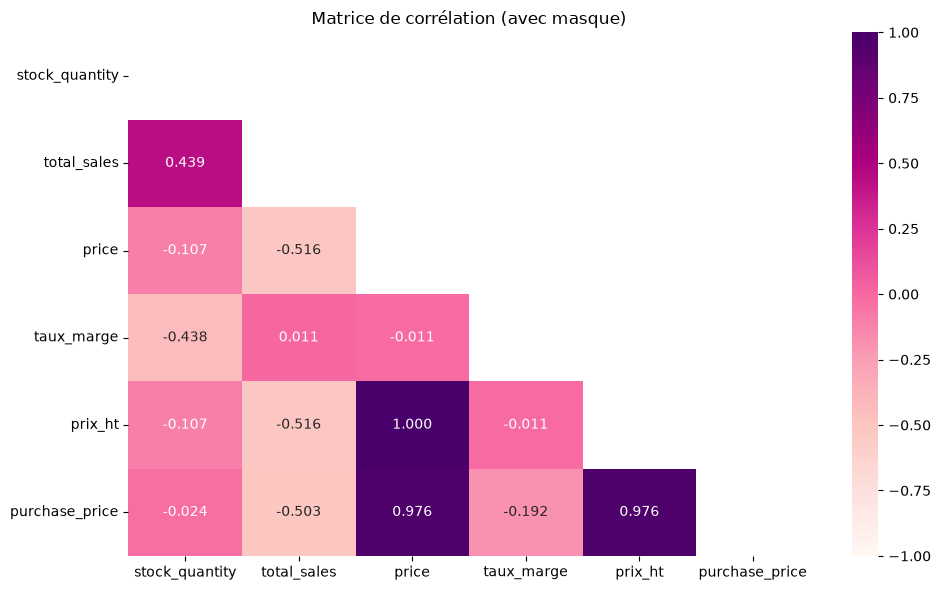

In [88]:
#Importation de Seaborn
import seaborn as sns

#Création d'un heatmap de correlation avec les variables stock, sales et price
#on peut également créer un mask pour n'afficher qu'une demi heatmap
import matplotlib.pyplot as plt
import numpy as np

# Étape 1 : Nettoyage préalable des données incohérentes
df_corr = df_final_clean[
    (df_final_clean["purchase_price_ht"] > 0) &
    (df_final_clean["price"] > 0) &
    (df_final_clean["taux_marge"].notna()) &
    (df_final_clean["taux_marge"] != np.inf)
].copy()

# Étape 2 : Sélection des colonnes pertinentes
colonnes_corr = ["stock_quantity", "total_sales", "price", "taux_marge", "prix_ht", "purchase_price"]

# Étape 3 : Création du masque pour n'afficher que la moitié inférieure
mask = np.triu(np.ones_like(df_corr[colonnes_corr].corr(), dtype=bool))

# Étape 4 : Création de la heatmap avec style proche du corrigé
plt.figure(figsize=(10, 6))
sns.heatmap(
    df_corr[colonnes_corr].corr(),
    vmin=-1, vmax=1, annot=True, mask=mask,
    cmap="RdPu",  # même palette que le corrigé
    fmt=".3f"
)
plt.title("Matrice de corrélation (avec masque)")
plt.tight_layout()
plt.show()


In [89]:
print(df_final_clean["taux_marge"].describe())

count    714.000000
mean       0.932204
std        0.115503
min       -0.836732
25%        0.878944
50%        0.935238
75%        0.995521
max        1.296950
Name: taux_marge, dtype: float64


In [90]:
#Que peut-on conclure des corrélations ?

Les prix sont logiquement cohérents entre eux
→ Forte corrélation entre price, prix_ht et purchase_price → ✅ les données tarifaires sont fiables et bien structurées.

Le stock influe sur les ventes
→ Corrélation modérée (r ≈ 0.44) entre stock_quantity et total_sales
→ Les produits bien approvisionnés se vendent mieux → impact logistique et prévisions.

Le prix ne détermine pas directement le volume des ventes
→ Corrélation très faible entre price et total_sales
→ On vend aussi bien des produits chers que bon marché → importance du positionnement produit.

Plus un produit coûte cher à l’achat, plus sa marge est difficile à préserver
→ Corrélation négative entre purchase_price et taux_marge
→ Il faut mieux surveiller les marges sur les produits haut de gamme.

<div style="border: 1px solid RGB(51,165,182);" ><h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Étape 5.5bis - Test de significativité des corrélations (p-value)</h3></div>

**Amélioration issue de la veille (Étape 1).** La heatmap ci-dessus donne une lecture visuelle des corrélations, mais un coefficient affiché seul ne dit rien de sa fiabilité statistique. On calcule ici, pour chaque paire de variables déjà présentée dans la heatmap, le coefficient de Pearson **et sa p-value** associée (`scipy.stats.pearsonr`). Le coefficient de Spearman (basé sur les rangs) est ajouté en complément, car `total_sales` est une variable très asymétrique (dominée par quelques best-sellers), ce qui limite la pertinence d'une hypothèse de linéarité stricte.Seuil de significativité retenu : p < 0,05.

In [91]:
#Test de significativité statistique des corrélations (Pearson + Spearman)
from scipy.stats import pearsonr, spearmanr
from itertools import combinations

resultats_corr = []

for col1, col2 in combinations(colonnes_corr, 2):
    sous_df = df_corr[[col1, col2]].dropna()
    if len(sous_df) < 3:
        continue
    r_pearson, p_pearson = pearsonr(sous_df[col1], sous_df[col2])
    r_spearman, p_spearman = spearmanr(sous_df[col1], sous_df[col2])
    resultats_corr.append({
        "Variable 1": col1,
        "Variable 2": col2,
        "Pearson r": round(r_pearson, 3),
        "Pearson p-value": round(p_pearson, 4),
        "Significatif (p<0.05)": "✅ Oui" if p_pearson < 0.05 else "❌ Non",
        "Spearman r": round(r_spearman, 3),
        "Spearman p-value": round(p_spearman, 4)
    })

df_resultats_corr = pd.DataFrame(resultats_corr).sort_values(by="Pearson r", ascending=False)
df_resultats_corr

,Variable 1,Variable 2,Pearson r,Pearson p-value,Significatif (p<0.05),Spearman r,Spearman p-value
10,price,prix_ht,1.000,0.0000,✅ Oui,1.000,0.0000
11,price,purchase_price,0.976,0.0000,✅ Oui,0.993,0.0000
14,prix_ht,purchase_price,0.976,0.0000,✅ Oui,0.993,0.0000
0,stock_quantity,total_sales,0.439,0.0000,✅ Oui,0.758,0.0000
6,total_sales,taux_marge,0.011,0.7628,❌ Non,-0.019,0.6175
9,price,taux_marge,-0.011,0.7636,❌ Non,-0.051,0.1742
12,taux_marge,prix_ht,-0.011,0.7636,❌ Non,-0.051,0.1742
4,stock_quantity,purchase_price,-0.024,0.5215,❌ Non,-0.551,0.0000
1,stock_quantity,price,-0.107,0.0043,✅ Oui,-0.572,0.0000
3,stock_quantity,prix_ht,-0.107,0.0043,✅ Oui,-0.572,0.0000


**Conclusion (résultats réels, exécution du 05/08/2026) :** sur les 15 paires testées, 11 sont significatives selon Pearson (p<0,05) et 12 selon Spearman. Les corrélations tarifaires (price / prix_ht / purchase_price) sont confirmées hautement significatives par les deux tests (p<0,0001), ce qui valide statistiquement la lecture déjà faite en V1. Le résultat le plus notable concerne stock_quantity vs purchase_price : Pearson conclut à une absence de lien (r=-0,024, p=0,52, non significatif), alors que Spearman révèle une relation monotone forte et hautement significative (r=-0,551, p<0,0001). Un simple coefficient de Pearson, comme celui affiché seul dans la heatmap du V1, aurait donc conduit à une conclusion statistiquement fausse sur cette paire précise — c'est la preuve chiffrée de l'intérêt d'ajouter Spearman en complément.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [92]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.  
# Exporter df_merge et df_final dans un seul fichier Excel, avec deux feuilles

with pd.ExcelWriter("resultats_ventes_nettoyees.xlsx", engine="xlsxwriter") as writer:
    df_final.to_excel(writer, sheet_name="Nettoyé_final", index=False)
